In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import heapq
import copy
from scipy.stats import mannwhitneyu, ttest_ind
from copy import deepcopy
from scipy.special import erfcinv

In [2]:
class Product:
    def __init__(self, name, initial_inventory, sell_prices, holding_cost, lead_time, s, S, demand_function):
        # Initial Parameters
        self.initial_inventory_amount = initial_inventory
        self.sell_prices_per_unit = sell_prices
        self.holding_cost_per_unit = holding_cost
        self.lead_time = lead_time
        self.demand_function = demand_function
        self.S = S
        self.s = s
        self.name = name
        
        self.reset_simulation_parameters()
        
    def reset_simulation_parameters(self):
        self.actual_inventory_amount = self.initial_inventory_amount
        
        self.total_inventory_holding_cost = 0
        self.total_order_amount = 0
        self.total_revenue = 0
        self.total_lost_amount = 0
    
    def charge_holding_cost(self, time):
        self.total_inventory_holding_cost += time * self.holding_cost_per_unit * self.actual_inventory_amount
    
    def get_revenue_and_losses(self, demand):
        w =  min(demand, self.actual_inventory_amount)
        self.total_revenue += w * self.sell_prices_per_unit
        self.total_lost_amount += (demand - w) * self.sell_prices_per_unit
        self.actual_inventory_amount -= w
       
    def summary(self):
        return {
        "product_name": self.name,
        "holding_cost": self.total_inventory_holding_cost,
        "order_amount": self.total_order_amount,
        "revenue": self.total_revenue,
        "lost_amount": self.total_lost_amount,
        "net_profit": self.total_revenue - self.total_inventory_holding_cost - self.total_order_amount
        }

In [3]:

class InventoryKStockSimulator:
    def __init__(self, customer_arrival_function, customer_demand_function, order_cost_function, 
                products: list["Product"], closing_time: int):
        
        # Parameters
        self.customer_arrival_function = customer_arrival_function
        self.customer_demand_function = customer_demand_function
        self.order_cost_function = order_cost_function
        self.products_list = products
        self.closing_time = closing_time
        
    
    def initialize_variables(self):
        # System State Variables
        for product in self.products_list:
            product.reset_simulation_parameters()
        
        # Events Variables
        self.time = 0
        self.events_queue = []
        self.actual_ordered_products = {i: False for i in range(len(self.products_list))}
        
    
    def process_customer(self, current_time):
        
        
        for product_id in self.customer_demand_function(len(self.products_list)):
            
            product = self.products_list[product_id]

            demand = product.demand_function()
            product.get_revenue_and_losses(demand)       
            
            if not self.actual_ordered_products[product_id] and product.actual_inventory_amount < product.s:
                amount = product.S - product.actual_inventory_amount
                heapq.heappush(self.events_queue, (current_time + product.lead_time, 'order', product_id, amount))
                self.actual_ordered_products[product_id] = True
            
        if self.time < self.closing_time:
            heapq.heappush(self.events_queue, (current_time + self.customer_arrival_function(), 'customer'))
            
        self.time = current_time
    
            
    def process_order(self, current_time, product_id, amount):
        
        product = self.products_list[product_id]
                
        product.total_order_amount += self.order_cost_function(amount)
        product.actual_inventory_amount += amount
        
        
        if product.actual_inventory_amount < product.s:
            amount = product.S - product.actual_inventory_amount
            heapq.heappush(self.events_queue, (current_time + product.lead_time, 'order', product_id, amount))
        else:
            self.actual_ordered_products[product_id] = False
        
        
        self.time = current_time

    
    def simulations(self,num_sim: int) -> list[list[dict]]:
        results = []
        for _ in range(num_sim):
            results.append(self.run())
        return results
    
    def run(self) -> list[dict]:
        
        self.initialize_variables()
        
        heapq.heappush(self.events_queue, (self.customer_arrival_function(), 'customer'))
        
        while self.events_queue:
            event = heapq.heappop(self.events_queue)
            
            for product in self.products_list:
                product.charge_holding_cost(event[0] - self.time)
            
            if event[1] == "customer":
                self.process_customer(event[0])
            else:
                self.process_order(event[0], event[2], event[3])

        return [product.summary() for product in self.products_list]

In [4]:
def customer_arrival_function(lamb = 1.0): 
    return np.random.exponential(lamb)

def customer_demand_function(max_length):
    if max_length <= 1:
        return [0]
    
    size = np.random.randint(low=1, high=max_length)
    return np.random.choice(max_length, size=size, replace=False)
         
def order_cost_function(y):
    return 5 + 2 * y 


¿Cual es la ganancia neta promedio de tres productos diferentes?

In [5]:
# Crear instancias de productos
products = [
    Product(
        name="Producto A (Alta rotación)",
        initial_inventory=30,
        sell_prices=15,
        holding_cost=0.3,
        lead_time=1,
        s=10,
        S=40,
        demand_function=lambda: np.random.poisson(8)
    ),
    Product(
        name="Producto B (Bajo costo)",
        initial_inventory=50,
        sell_prices=8,
        holding_cost=0.1,
        lead_time=3,
        s=15,
        S=60,
        demand_function=lambda: np.random.poisson(5)
    ),
    Product(
        name="Producto C (Lujo)",
        initial_inventory=10,
        sell_prices=50,
        holding_cost=1.2,
        lead_time=2,
        s=3,
        S=25,
        demand_function=lambda: np.random.poisson(2)
    )
]


# Configurar simulador
sim = InventoryKStockSimulator(
    customer_arrival_function=customer_arrival_function,
    customer_demand_function=customer_demand_function,
    order_cost_function=order_cost_function,
    products=products,
    closing_time=100
)


In [ ]:
acceptable_d = 30
n_sim = 100
c = erfcinv(0.005)

# Diccionario para guardar los datos por producto
data_per_product_dm = {}

while True:
    summaries_list = sim.simulations(n_sim)
    
    for summaries in summaries_list:
        for summary in summaries:
            name = summary["product_name"]
            if name not in data_per_product_dm:
                data_per_product_dm[name] = {
                    "net_profit": [],
                    "holding_cost": [],
                    "order_amount": [],
                    "revenue": [],
                    "lost_amount": []
                }
            for k in data_per_product_dm[name]:
                data_per_product_dm[name][k].append(summary[k])
    
    converged = True
    for name, metrics in data_per_product_dm.items():
        std = np.std(metrics["net_profit"])  # Puedes cambiar por otra métrica si lo deseas
        n = len(metrics["net_profit"])
        margin = c * (std / np.sqrt(n))
        if margin > acceptable_d:
            converged = False
            break
      
    if converged:
        print(f"Estimate means have converged with {n} simulations:\n")
        for name, metrics in data_per_product_dm.items():
            print(f"--- {name} ---")
            for k in metrics:
                print(f"{k}: {np.mean(metrics[k]):.2f}")
            print()
        break
    
    n_sim = 30
    



Estimate means have converged with 2650 simulations:

--- Producto A (Alta rotación) ---
net_profit: 4206.81
holding_cost: 726.30
order_amount: 815.70
revenue: 5748.82
lost_amount: 369.28

--- Producto B (Bajo costo) ---
net_profit: 1147.26
holding_cost: 328.67
order_amount: 496.19
revenue: 1972.13
lost_amount: 50.44

--- Producto C (Lujo) ---
net_profit: 2966.08
holding_cost: 1583.09
order_amount: 222.15
revenue: 4771.32
lost_amount: 315.66



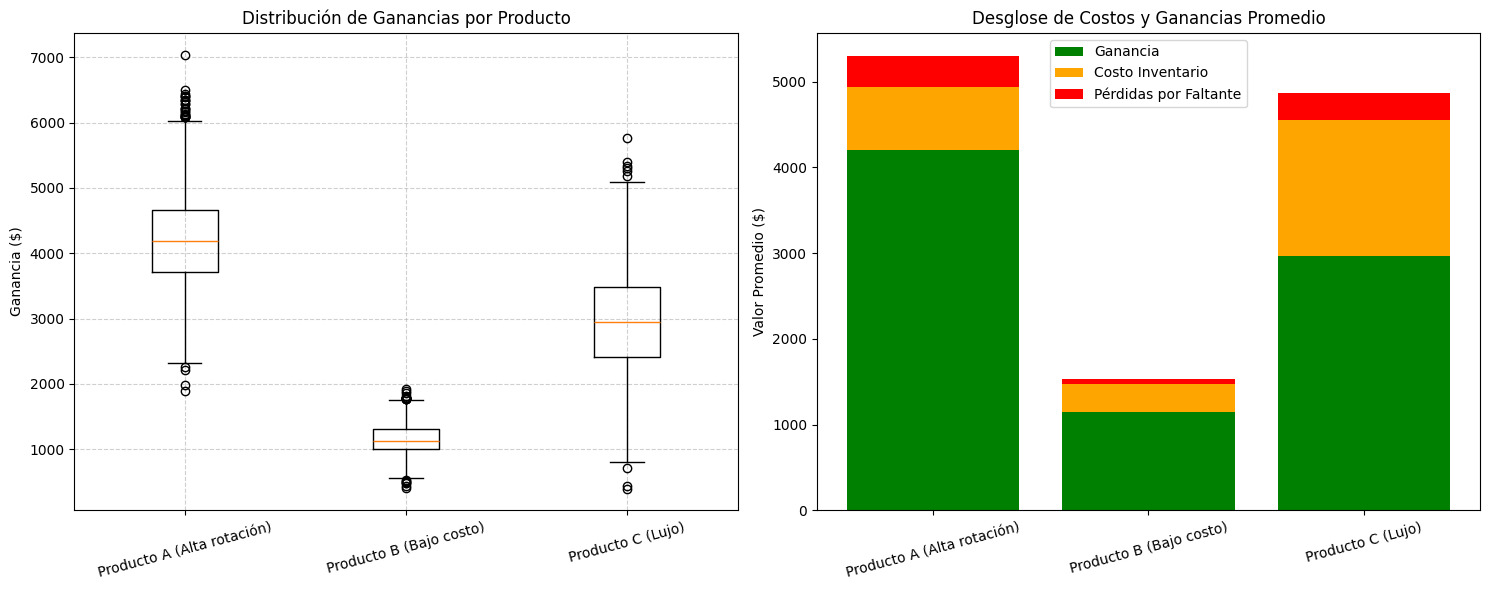

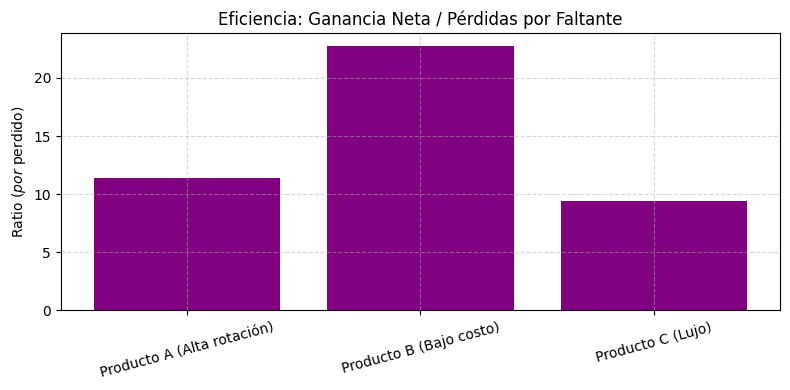

In [ ]:
def analyze_data_per_product(data_per_product):
    product_names = list(data_per_product.keys())
    n_products = len(product_names)

    # --- Recuperar vectores ---
    profits_by_product = [data_per_product[name]['net_profit'] for name in product_names]
    holding_by_product = [data_per_product[name]['holding_cost'] for name in product_names]
    lost_by_product = [data_per_product[name]['lost_amount'] for name in product_names]

    # --- Subplots ---
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))
    
    # --- Gráfico de Caja: Ganancias ---
    axs[0].boxplot(profits_by_product, labels=product_names)
    axs[0].set_title('Distribución de Ganancias por Producto')
    axs[0].set_ylabel('Ganancia ($)')
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[0].tick_params(axis='x', rotation=15)

    # --- Gráfico de Barras Apiladas: Costos, Ganancias, Pérdidas ---
    mean_gains = [np.mean(profits) for profits in profits_by_product]
    mean_holding = [np.mean(holding) for holding in holding_by_product]
    mean_lost = [np.mean(lost) for lost in lost_by_product]

    bottom = np.zeros(n_products)
    indices = np.arange(n_products)

    axs[1].bar(indices, mean_gains, label='Ganancia', color='green')
    axs[1].bar(indices, mean_holding, label='Costo Inventario', bottom=mean_gains, color='orange')
    axs[1].bar(indices, mean_lost, label='Pérdidas por Faltante', bottom=np.array(mean_gains)+np.array(mean_holding), color='red')

    axs[1].set_title('Desglose de Costos y Ganancias Promedio')
    axs[1].set_ylabel('Valor Promedio ($)')
    axs[1].set_xticks(indices)
    axs[1].set_xticklabels(product_names, rotation=15)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Gráfico de Barras: Ganancia por cada dólar perdido ---
    ratios = [
        np.mean(data_per_product[name]['net_profit']) / np.mean(data_per_product[name]['lost_amount'])
        if np.mean(data_per_product[name]['lost_amount']) > 0 else np.nan
        for name in product_names
    ]
    plt.figure(figsize=(8, 4))
    plt.bar(product_names, ratios, color='purple')
    plt.title('Eficiencia: Ganancia Neta / Pérdidas por Faltante')
    plt.ylabel('Ratio ($ por $ perdido)')
    plt.xticks(rotation=15)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

analyze_data_per_product(data_per_product_dm)

 ¿Qué producto es más afectado por cambios en la demanda?


--- Demand mean: 2 ---
Converged after 3430 simulations

--- Demand mean: 4 ---
Converged after 6940 simulations

--- Demand mean: 6 ---
Converged after 10840 simulations

--- Demand mean: 8 ---
Converged after 14620 simulations

--- Demand mean: 10 ---
Converged after 18040 simulations

--- Demand mean: 12 ---
Converged after 23260 simulations

--- Demand mean: 14 ---
Converged after 25150 simulations


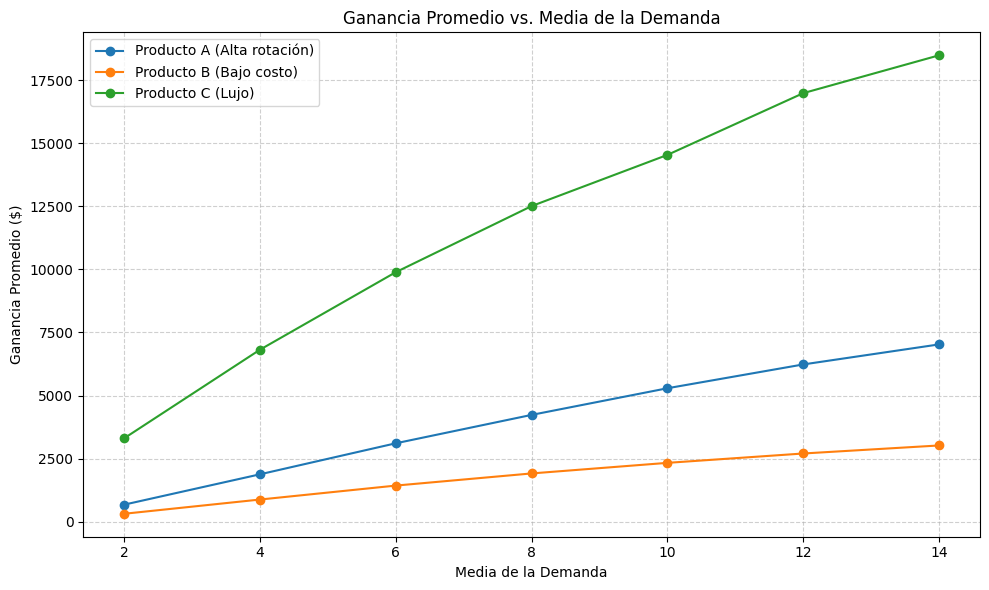

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfcinv
from copy import deepcopy

def demand_factory(mean, std=2):
    return lambda: max(0, np.random.normal(loc=mean, scale=std))

def estimate_profit_vs_demand(products, demand_means, acceptable_d=30, initial_sim=100):
    results = {p.name: [] for p in products}

    for mean in demand_means:
        print(f"\n--- Demand mean: {mean} ---")

        # Crear productos con la misma configuración excepto la nueva función de demanda
        updated_products = []
        for p in products:
            prod = deepcopy(p)
            prod.demand_function = demand_factory(mean)
            updated_products.append(prod)

        # Crear nueva instancia del simulador
        sim = InventoryKStockSimulator(
            customer_arrival_function=customer_arrival_function,
            customer_demand_function=customer_demand_function,
            order_cost_function=order_cost_function,
            products=updated_products,
            closing_time=100
        )
        
        # Simulación iterativa hasta convergencia
        c = erfcinv(0.005)
        data_per_product_dm = {p.name: [] for p in updated_products}
        n_sim = initial_sim

        while True:
            summaries_list = sim.simulations(n_sim)
    
            for summaries in summaries_list:
                for summary in summaries:
                    name = summary['product_name']
                    data_per_product_dm[name].append(summary['net_profit'])

            converged = True
            for name in data_per_product_dm:
                values = data_per_product_dm[name]
                std = np.std(values)
                margin = c * (std / np.sqrt(len(values)))
                if margin > acceptable_d:
                    converged = False
                    break

            if converged:
                print(f"Converged after {sum(len(v) for v in data_per_product_dm.values()) // len(products)} simulations")
                break
            n_sim = 30

        for name in results:
            mean_profit = np.mean(data_per_product_dm[name])
            results[name].append(mean_profit)

    return results

def plot_profit_vs_demand(results, demand_means):
    plt.figure(figsize=(10, 6))
    for name, profits in results.items():
        plt.plot(demand_means, profits, marker='o', label=name)
    plt.title('Ganancia Promedio vs. Media de la Demanda')
    plt.xlabel('Media de la Demanda')
    plt.ylabel('Ganancia Promedio ($)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

demand_means = [2, 4, 6, 8, 10, 12, 14]
results_price_sensitivity = estimate_profit_vs_demand(products, demand_means)
plot_profit_vs_demand(results_price_sensitivity, demand_means)


¿Qué pasa si cambian los precios de venta?

--- Sell prices multiplier 0.6 ---
Converged after 970 simulations 

--- Sell prices multiplier 0.8 ---
Converged after 1720 simulations 

--- Sell prices multiplier 1.0 ---
Converged after 2590 simulations 

--- Sell prices multiplier 1.2 ---
Converged after 3850 simulations 

--- Sell prices multiplier 1.4 ---
Converged after 5140 simulations 

--- Sell prices multiplier 1.6 ---
Converged after 6700 simulations 

--- Sell prices multiplier 1.8 ---
Converged after 8710 simulations 

--- Sell prices multiplier 2.0 ---
Converged after 10390 simulations 



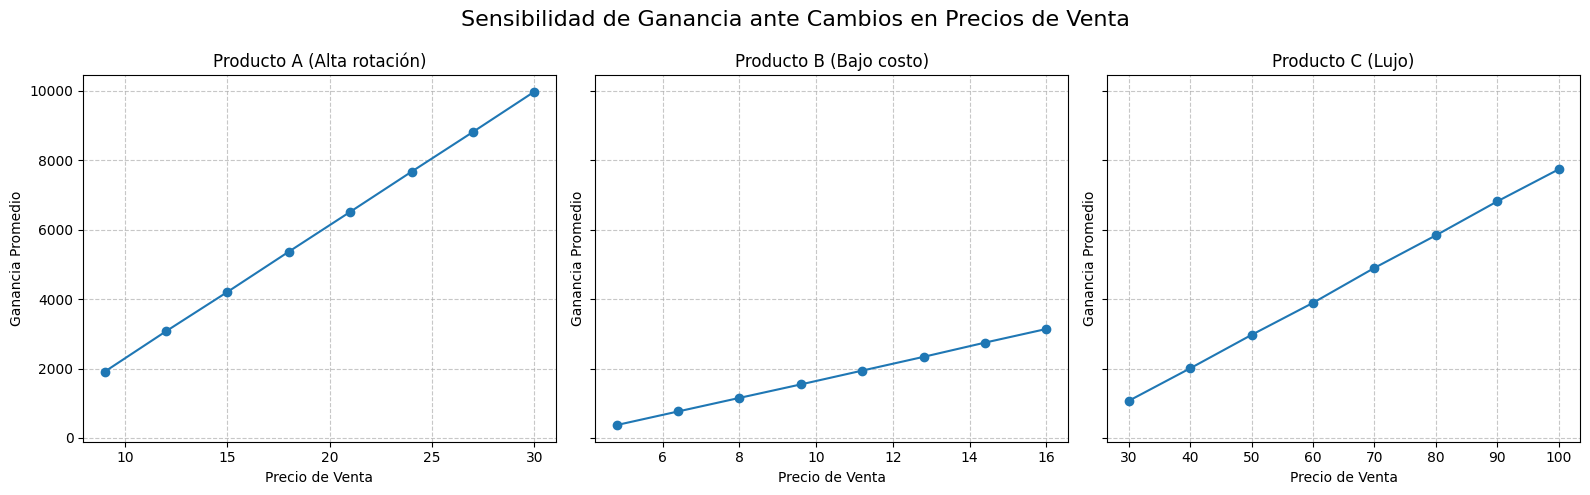

In [38]:
def simulate_price_sensitivity(products: list[Product], price_multipliers, acceptable_d=30, n_sim_init=100):

    confidence_z = erfcinv(0.005)
    results_per_product_sp = {p.name: {"prices": [], "profits": []} for p in products}

    for multiplier in price_multipliers:
        print(f"--- Sell prices multiplier {multiplier} ---")
        # Modificar precios
        updated_products = deepcopy(products)
        for p in updated_products:
            p.sell_prices_per_unit *= multiplier

        data_per_product_sp = {p.name: {"net_profit": []} for p in updated_products}
        n_sim = n_sim_init

        # Crear nueva instancia del simulador
        sim = InventoryKStockSimulator(
            customer_arrival_function=customer_arrival_function,
            customer_demand_function=customer_demand_function,
            order_cost_function=order_cost_function,
            products=updated_products,
            closing_time=100
        )
        
        while True:
            summaries_list = sim.simulations(n_sim)
    
            for summaries in summaries_list:
                for summary in summaries:
                    name = summary["product_name"]
                    data_per_product_sp[name]["net_profit"].append(summary["net_profit"])

            converged = True
            for name, data in data_per_product_sp.items():
                std = np.std(data["net_profit"])
                margin = confidence_z * std / np.sqrt(len(data["net_profit"]))
                if margin >= acceptable_d:
                    converged = False
                    break

            if converged:
                print(f"Converged after {len(data['net_profit'])} simulations \n")
                for name in results_per_product_sp:
                    results_per_product_sp[name]["prices"].append(
                        next(p.sell_prices_per_unit for p in updated_products if p.name == name)
                    )
                    results_per_product_sp[name]["profits"].append(np.mean(data_per_product_sp[name]["net_profit"]))
                break

            n_sim = 30  # agregar más simulaciones

    return results_per_product_sp

def plot_price_sensitivity(results_per_product_sp):
    fig, axs = plt.subplots(1, len(results_per_product_sp), figsize=(16, 5), sharey=True)
    fig.suptitle("Sensibilidad de Ganancia ante Cambios en Precios de Venta", fontsize=16)

    for ax, (product, data) in zip(axs, results_per_product_sp.items()):
        prices = data["prices"]
        profits = data["profits"]

        ax.plot(prices, profits, marker='o')
        ax.set_title(product)
        ax.set_xlabel("Precio de Venta")
        ax.set_ylabel("Ganancia Promedio")
        ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    
price_multipliers = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
results_price_sensitivity = simulate_price_sensitivity(products, price_multipliers=price_multipliers)
plot_price_sensitivity(results_price_sensitivity)

